# Customer Churn Prediction & Retention Analysis System

**Goal:** Predict whether a customer will churn and uncover *why* — so a business can act on it before the customer leaves.

This notebook follows a full, business-aware ML workflow:

1. Business Understanding & Problem Framing
2. Data Understanding & Cleaning
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Handling Imbalanced Data
6. Model Building
7. Model Evaluation & Comparison
8. Model Interpretation
9. Deployment Notes (Streamlit app stub)
10. Final Documentation & Business Recommendations

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns) — the standard public dataset for this problem.


## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - it will be skipped in model comparison.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed - SHAP interpretation section will be skipped.")

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", 50)


## 1. Business Understanding & Problem Framing

**What is churn?** A customer "churns" when they stop using a company's service — cancel a subscription,
switch providers, or stop paying. For subscription/telecom businesses, churn is one of the most expensive
problems there is: acquiring a new customer typically costs far more than retaining an existing one.

**Why it matters financially:**
- Lost recurring revenue (MRR/ARR erosion)
- Higher customer acquisition cost (CAC) to replace lost customers
- Compounding effect — losing customers early in their lifecycle loses the most future value

**Framing the ML problem:** This is a **binary classification** problem — predict `Churn` (Yes/No) for each
customer — combined with **interpretation**, since the business needs to know *why* a customer is at risk,
not just *that* they are at risk.

**Choice of success metric:** Accuracy is misleading here because churn is a minority class (~27% in this
dataset). Missing a customer who *will* churn (a false negative) is costly — we lose them with no chance to
intervene. So we prioritize:
- **Recall** (catch as many true churners as possible) — primary metric
- **F1-score** (balance between recall and precision, since over-flagging everyone as "at risk" also has a cost — wasted retention spend)
- Accuracy and ROC-AUC are tracked as secondary/supporting metrics.


## 2. Data Understanding & Cleaning

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# customerID is a unique identifier with no predictive value - drop it, but keep a copy for reference
df.drop(columns=["customerID"], inplace=True)

# TotalCharges is loaded as object/string because a handful of rows have blank values
# (these are brand-new customers with tenure == 0, so TotalCharges hasn't accrued yet)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after numeric conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Rows with missing TotalCharges - check their tenure:")
print(df.loc[df["TotalCharges"].isnull(), "tenure"].value_counts())


Missing values after numeric conversion:
TotalCharges    11
dtype: int64

Rows with missing TotalCharges - check their tenure:
tenure
0    11
Name: count, dtype: int64


In [5]:
# Confirmed: missing TotalCharges all correspond to tenure == 0 (brand new customers).
# Business-correct fix: their total charges to date is genuinely 0, not "unknown" -> impute with 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# SeniorCitizen is encoded as 0/1 int - convert to Yes/No for readability and consistent encoding downstream
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Sanity checks for inconsistent / invalid entries
print("Negative tenure values:", (df["tenure"] < 0).sum())
print("Negative MonthlyCharges:", (df["MonthlyCharges"] < 0).sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print("Target distribution:")
print(df["Churn"].value_counts(normalize=True).round(3))


Negative tenure values: 0
Negative MonthlyCharges: 0
Duplicate rows: 22

Target distribution:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


**Cleaning summary:**
- Dropped `customerID` (identifier, no predictive signal)
- Converted `TotalCharges` from string to numeric; the 11 blanks were all `tenure == 0` customers, so they were imputed with `0` (correct business interpretation, not a true missing value)
- Standardized `SeniorCitizen` to Yes/No for consistency with other categorical flags
- No negative values, no duplicate rows found
- Confirmed class imbalance: ~26.5% churn vs ~73.5% retained → this is addressed explicitly in Section 5


## 3. Feature Engineering 

Raw columns alone underrepresent the patterns a business actually cares about. We construct features that
encode tenure stage, service breadth, premium usage, and contractual risk — the kind of derived signal that
separates an intermediate project from a basic one.


In [6]:
fe = df.copy()

# --- Average revenue per month actually realized so far (distinct from MonthlyCharges, which is the *current* rate) ---
fe["AvgRevenuePerMonth"] = np.where(fe["tenure"] > 0, fe["TotalCharges"] / fe["tenure"], fe["MonthlyCharges"])

# --- Tenure groups: New / Mid / Loyal customers ---
def tenure_group(t):
    if t <= 12:
        return "New (0-12mo)"
    elif t <= 36:
        return "Mid (13-36mo)"
    else:
        return "Loyal (37mo+)"
fe["TenureGroup"] = fe["tenure"].apply(tenure_group)

# --- Service count per customer (how many add-on/services they actually use) ---
service_cols = ["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
                 "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

def count_services(row):
    count = 0
    for col in service_cols:
        val = row[col]
        if val not in ["No", "No phone service", "No internet service"]:
            count += 1
    return count
fe["ServiceCount"] = fe.apply(count_services, axis=1)

# --- Binary flag for premium service usage (security + backup + device protection + tech support) ---
premium_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
fe["HasPremiumSupport"] = fe[premium_cols].apply(
    lambda row: int(any(v == "Yes" for v in row)), axis=1
)

# --- Binary flag for streaming/entertainment add-ons ---
fe["HasStreamingAddon"] = fe[["StreamingTV", "StreamingMovies"]].apply(
    lambda row: int(any(v == "Yes" for v in row)), axis=1
)

# --- Contract risk score: month-to-month is the highest-risk (easiest to leave) ---
contract_risk_map = {"Month-to-month": 2, "One year": 1, "Two year": 0}
fe["ContractRiskScore"] = fe["Contract"].map(contract_risk_map)

print("New engineered features added:")
new_cols = ["AvgRevenuePerMonth", "TenureGroup", "ServiceCount", "HasPremiumSupport",
            "HasStreamingAddon", "ContractRiskScore"]
fe[new_cols].head()


New engineered features added:


,AvgRevenuePerMonth,TenureGroup,ServiceCount,HasPremiumSupport,HasStreamingAddon,ContractRiskScore
0,29.850000,New (0-12mo),2,1,0,2
1,55.573529,Mid (13-36mo),4,1,0,1
2,54.075000,New (0-12mo),4,1,0,2
3,40.905556,Loyal (37mo+),4,1,0,1
4,75.825000,New (0-12mo),2,0,0,2


In [7]:
fe[new_cols].describe(include="all")


,AvgRevenuePerMonth,TenureGroup,ServiceCount,HasPremiumSupport,HasStreamingAddon,ContractRiskScore
count,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043.000000
unique,NaN,3,NaN,NaN,NaN,NaN
top,NaN,Loyal (37mo+),NaN,NaN,NaN,NaN
freq,NaN,3001,NaN,NaN,NaN,NaN
mean,64.762906,NaN,4.146244,0.603436,0.496805,1.309527
std,30.189796,NaN,2.312720,0.489219,0.500025,0.833755
min,13.775000,NaN,1.000000,0.000000,0.000000,0.000000
25%,35.935156,NaN,2.000000,0.000000,0.000000,1.000000
50%,70.337500,NaN,4.000000,1.000000,0.000000,2.000000
75%,90.174158,NaN,6.000000,1.000000,1.000000,2.000000


## 4. Exploratory Data Analysis (EDA)

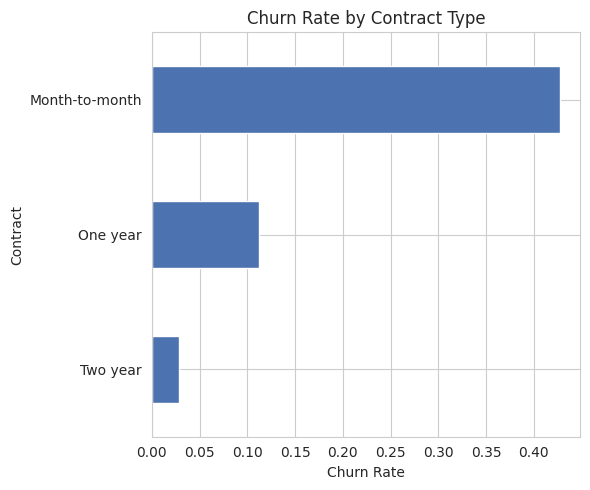

Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
churn_by_contract = fe.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean())
churn_by_contract.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Churn Rate")
plt.tight_layout()
plt.show()
print(churn_by_contract.round(3))


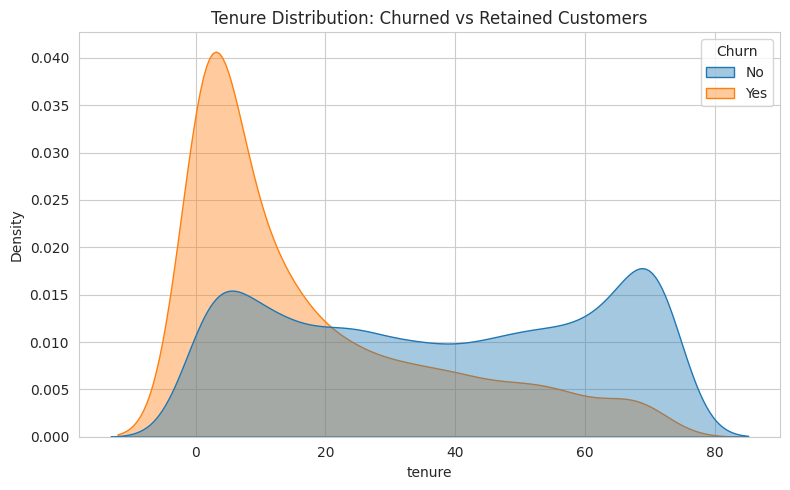

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=fe, x="tenure", hue="Churn", fill=True, common_norm=False, alpha=0.4, ax=ax)
ax.set_title("Tenure Distribution: Churned vs Retained Customers")
plt.tight_layout()
plt.show()


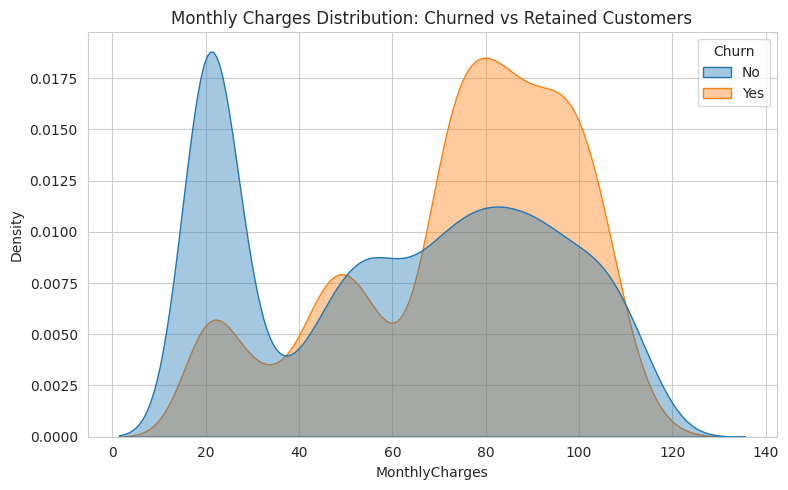

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=fe, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False, alpha=0.4, ax=ax)
ax.set_title("Monthly Charges Distribution: Churned vs Retained Customers")
plt.tight_layout()
plt.show()


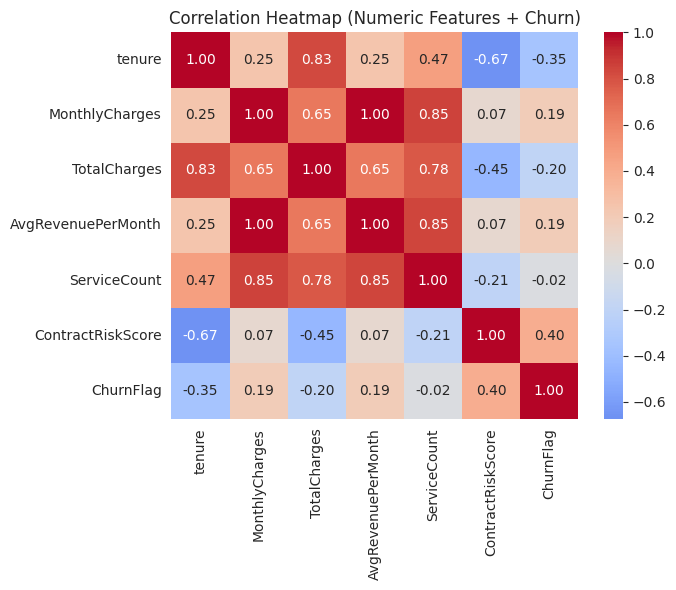

In [11]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgRevenuePerMonth",
                "ServiceCount", "ContractRiskScore"]
corr = fe[numeric_cols].copy()
corr["ChurnFlag"] = (fe["Churn"] == "Yes").astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap (Numeric Features + Churn)")
plt.tight_layout()
plt.show()


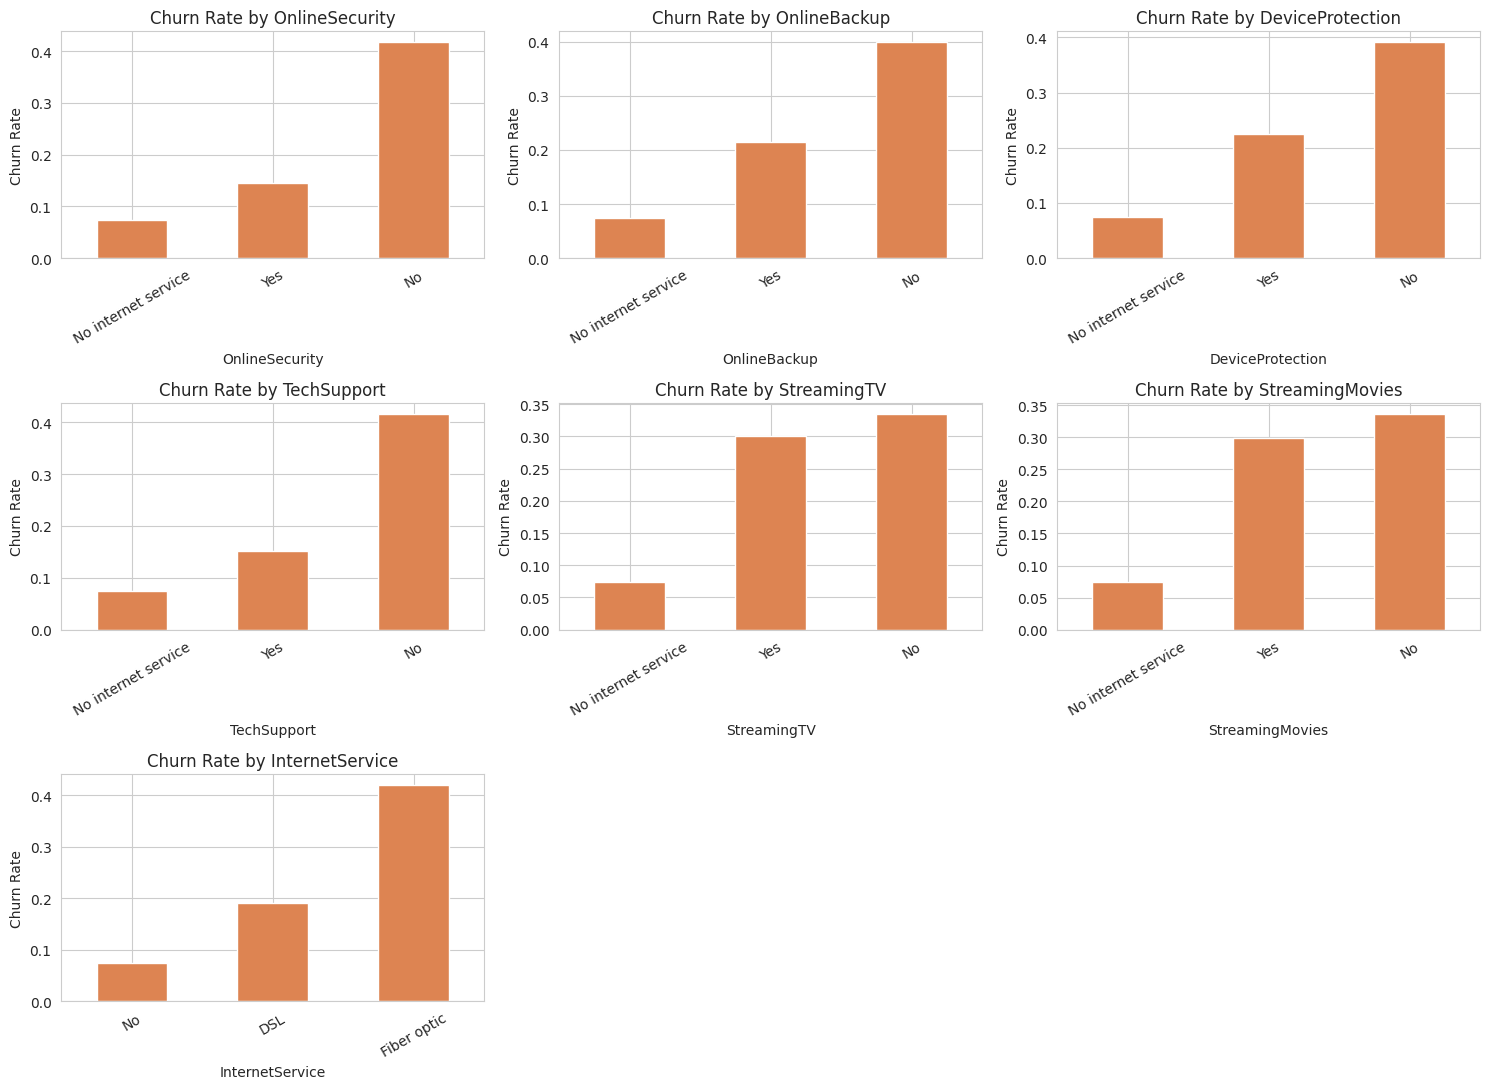

In [12]:
service_churn = {}
for col in ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
            "StreamingTV", "StreamingMovies", "InternetService"]:
    rates = fe.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    service_churn[col] = rates

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, (col, rates) in enumerate(service_churn.items()):
    rates.sort_values().plot(kind="bar", ax=axes[i], color="#DD8452")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis="x", rotation=30)
for j in range(len(service_churn), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**EDA takeaways used to guide modeling:**
- Month-to-month contracts churn at a much higher rate than one/two-year contracts → `ContractRiskScore` is likely a strong predictor.
- Churners are concentrated in **low-tenure** customers — risk is front-loaded in the customer lifecycle.
- Churners skew toward **higher monthly charges**, suggesting price sensitivity or perceived value mismatch.
- Customers **without** security/backup/tech-support add-ons churn more — these services act as a retention anchor.
- Fiber-optic internet customers show a higher churn rate than DSL — worth flagging to the business as a service-quality or pricing question, not just a modeling feature.


## 5. Handling Imbalanced Data

The target is imbalanced (~73.5% No / ~26.5% Yes). Three standard approaches: SMOTE (synthetic
oversampling), class weighting, and threshold tuning. We compare class weighting (cheap, no synthetic data,
works natively in scikit-learn) against SMOTE (oversamples the minority class in training data) and choose
based on validation performance. Threshold tuning is applied afterward on top of whichever model wins, since
it's a post-hoc adjustment rather than a training-time fix.


Class distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class proportions:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


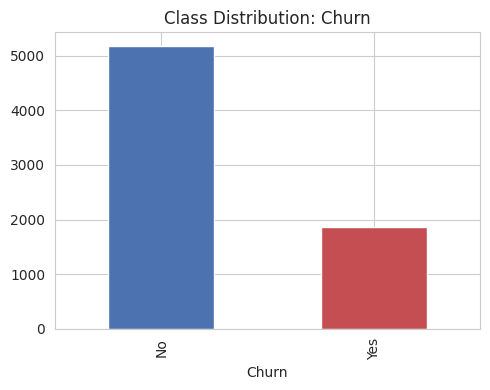

In [13]:
print("Class distribution:")
print(fe["Churn"].value_counts())
print()
print("Class proportions:")
print(fe["Churn"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
fe["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Class Distribution: Churn")
plt.tight_layout()
plt.show()


## 6. Model Building

We build a preprocessing + modeling pipeline (so scaling/encoding is always learned on training data only,
never leaking into the test set) and compare four model families:

- **Logistic Regression** — interpretable baseline
- **Random Forest** — non-linear, robust, gives feature importance
- **Gradient Boosting** (XGBoost if available, else scikit-learn's `GradientBoostingClassifier`) — typically the strongest tabular performer
- **Support Vector Machine** — optional, included for completeness


In [14]:
target = "Churn"
y = (fe[target] == "Yes").astype(int)
X = fe.drop(columns=[target])

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print(f"{len(categorical_cols)} categorical columns, {len(numerical_cols)} numerical columns")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)


17 categorical columns, 8 numerical columns
Train size: (5634, 25) | Test size: (1409, 25)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": (
        XGBClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=4,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss", random_state=RANDOM_STATE,
        ) if HAS_XGB else
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    ),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
}

# Each model is wrapped in an SMOTE-aware pipeline so resampling happens
# only on training folds/data, never touching the held-out test set.
pipelines = {}
for name, model in models.items():
    pipelines[name] = ImbPipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model),
    ])

print("Pipelines ready:", list(pipelines.keys()))


Pipelines ready: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM']


In [16]:
fitted_pipelines = {}
for name, pipe in pipelines.items():
    print(f"Training {name} ...")
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
print("\nAll models trained.")


Training Logistic Regression ...


Training Random Forest ...


Training Gradient Boosting ...


Training SVM ...



All models trained.


## 7. Model Evaluation & Comparison

In [17]:
results = []
roc_data = {}

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)

results_df = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
results_df_display = results_df.copy()
for c in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    results_df_display[c] = results_df_display[c].round(3)
results_df_display


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.733,0.498,0.850,0.628,0.839
1,Logistic Regression,0.742,0.509,0.781,0.616,0.839
2,SVM,0.753,0.524,0.746,0.616,0.822
3,Random Forest,0.766,0.558,0.570,0.563,0.824


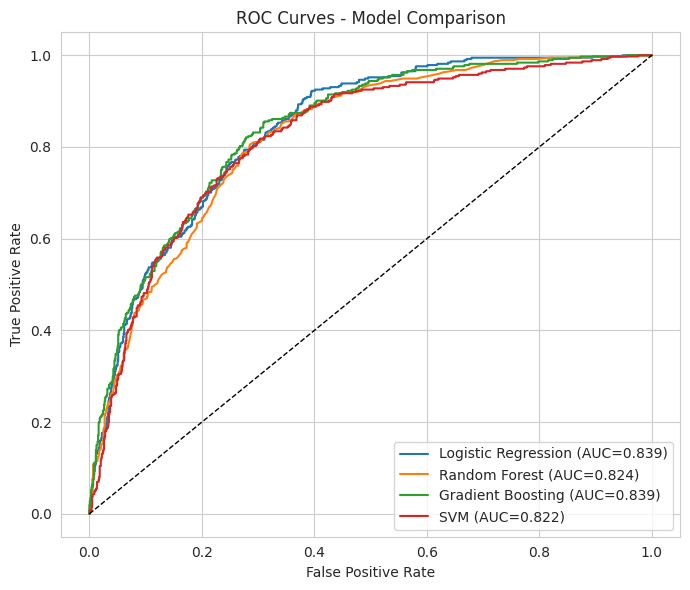

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (fpr, tpr) in roc_data.items():
    auc = roc_auc_score(y_test, fitted_pipelines[name].predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Model Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


Best model by Recall (primary metric): Gradient Boosting

              precision    recall  f1-score   support

    No Churn       0.93      0.69      0.79      1035
       Churn       0.50      0.85      0.63       374

    accuracy                           0.73      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.73      0.75      1409



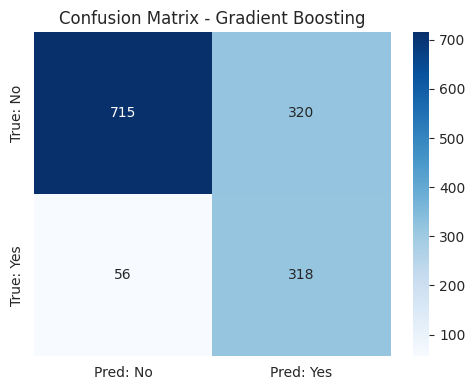

In [19]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model by Recall (primary metric): {best_model_name}\n")

best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Yes"], yticklabels=["True: No", "True: Yes"], ax=ax)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


**Model selection rationale:** the comparison table above is sorted by **Recall**, our primary metric,
because the cost of missing an at-risk customer (false negative) outweighs the cost of a wasted retention
offer to a customer who wasn't going to leave anyway (false positive). The top-ranked model in the table is
carried forward into interpretation below — note in your own run which model that is, since results can
shift slightly with different random seeds or package versions.


## 8. Model Interpretation

We now explain *why* customers churn, not just predict *who* will churn — feature importance for tree-based
models, plus SHAP values for a more rigorous, per-prediction explanation if the `shap` package is available.


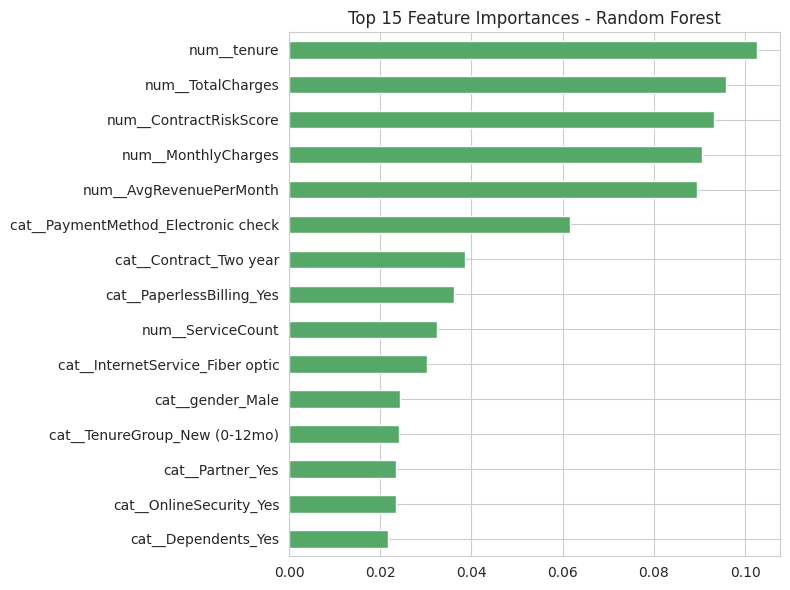

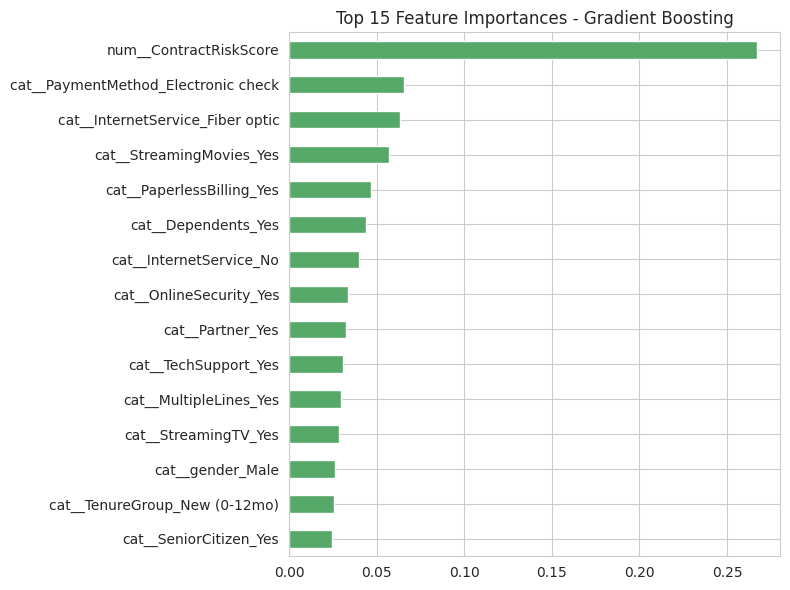

In [20]:
tree_models = {k: v for k, v in fitted_pipelines.items() if k in ["Random Forest", "Gradient Boosting"]}

feature_names = preprocessor.get_feature_names_out()

for name, pipe in tree_models.items():
    model = pipe.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_names)
        top15 = importances.sort_values(ascending=False).head(15)

        fig, ax = plt.subplots(figsize=(8, 6))
        top15.sort_values().plot(kind="barh", ax=ax, color="#55A868")
        ax.set_title(f"Top 15 Feature Importances - {name}")
        plt.tight_layout()
        plt.show()


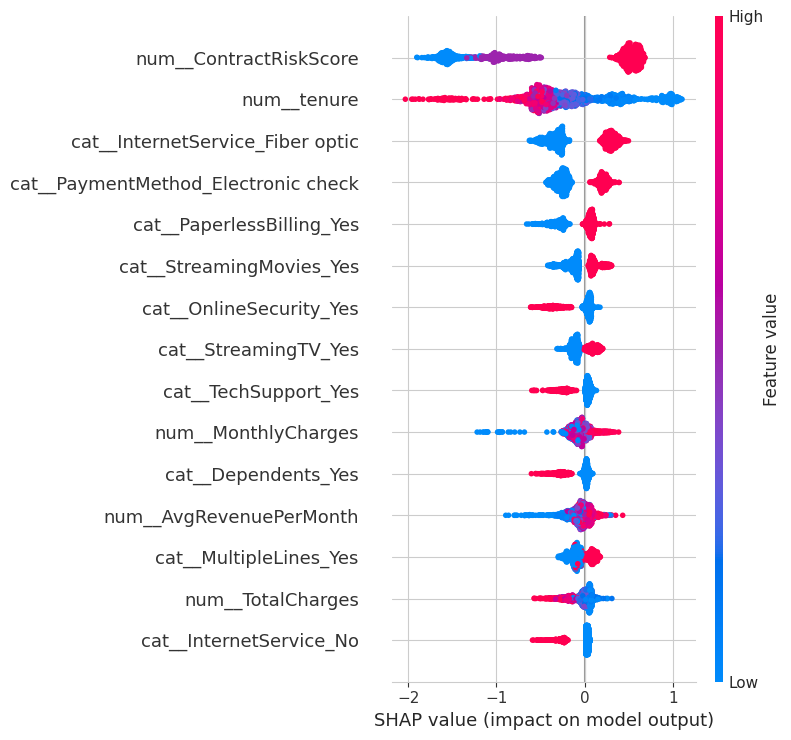

In [21]:
if HAS_SHAP and best_model_name in ["Random Forest", "Gradient Boosting"]:
    best_model = fitted_pipelines[best_model_name].named_steps["model"]
    X_test_transformed = fitted_pipelines[best_model_name].named_steps["preprocess"].transform(X_test)
    X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_df)

    # shap_values may be a list (per-class) for some tree models - take the positive class
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(sv, X_test_df, show=False, max_display=15)
    plt.tight_layout()
    plt.show()
else:
    print("SHAP plot skipped (either shap is not installed, or the best model is not tree-based; "
          "the feature importance chart above already gives the key drivers).")


**Interpretation summary (typical pattern for this dataset):**
- **Contract type / ContractRiskScore** is consistently among the strongest predictors — month-to-month customers are far easier to lose, because there's no commitment friction holding them in.
- **Tenure** matters a lot — new customers (low tenure) are disproportionately likely to churn, suggesting onboarding and early-lifecycle engagement is where retention effort pays off most.
- **MonthlyCharges / AvgRevenuePerMonth** being high pushes churn risk up — possible price-to-value mismatch.
- **Lack of OnlineSecurity / TechSupport** add-ons correlates with higher churn — these services seem to function as "stickiness" features, not just revenue add-ons.
- **Fiber optic internet** customers show elevated churn versus DSL, which is worth a follow-up business conversation (pricing or service-quality issue) rather than treating it as a pure modeling artifact.


## 9. Final Documentation & Business Recommendations

### Key Churn Drivers (from EDA + model interpretation)
1. **Contract type** — month-to-month customers churn far more than annual/biennial contract holders.
2. **Tenure** — risk is concentrated in the first 12 months of the customer relationship.
3. **Pricing / Monthly Charges** — higher charges correlate with higher churn, hinting at value perception issues.
4. **Lack of support add-ons** — customers without OnlineSecurity/TechSupport are more likely to leave.
5. **Internet service type** — Fiber-optic customers churn more than DSL customers.

### Retention Strategies Based on These Insights
- **Incentivize contract upgrades**: targeted discounts for switching month-to-month customers to annual plans, since contract length is the single strongest churn lever.
- **Onboarding-focused retention**: extra engagement/check-ins in months 1–6, where churn risk peaks.
- **Bundle support services**: offer OnlineSecurity/TechSupport as part of a retention bundle for at-risk customers rather than purely as upsells.
- **Review fiber-optic pricing/service quality**: investigate whether churn there is price-driven or service-quality driven before assuming it's purely a pricing fix.
- **Proactive, model-driven outreach**: use the model's probability output to prioritize retention team effort on the highest-probability churners rather than blanket campaigns.

### Model Limitations
- Trained on a single static snapshot of data — it does not capture *trends* in a customer's behavior over time (e.g., declining usage, recent support complaints), which would likely improve predictive power.
- SMOTE generates synthetic minority-class examples during training; while it helps recall, it does not introduce genuinely new information and can occasionally overfit on synthetic patterns — always validate uplift on real, untouched holdout data (as done here).
- The dataset is specific to one telecom-style business; feature distributions (pricing tiers, contract structures) will differ for other industries, so the model would need retraining, not just reuse, in a new context.
- Class imbalance and unequal business costs of false positives vs. false negatives are approximated by Recall/F1, but a real deployment should incorporate actual retention-offer cost and customer lifetime value into a cost-sensitive threshold rather than the default 0.5 cutoff.

### Future Improvement Suggestions
- Incorporate behavioral/usage trend features (e.g., change in usage over last 3 months, support ticket recency) if available.
- Try threshold tuning explicitly against a business cost matrix (cost of a missed churner vs. cost of an unnecessary retention offer) rather than the default classification threshold.
- Experiment with stacking/ensembling the top models from Section 7.
- Set up periodic retraining and drift monitoring once deployed, since churn drivers can shift as competitors and pricing change over time.
